# eoml walkthrough

End-to-end tour of the project: train the land cover classifier on EuroSAT, evaluate it, then retrieve an arbitrary Sentinel-2 scene from the Planetary Computer and run both analyses on it — land cover classification and NDVI.

```
EuroSAT (L1C chips) ──▶ train ──▶ checkpoint ─────────┐
                                                      ▼
STAC search ──▶ load_scene (L2A, 10 m grid) ──▶ classify_scene ──▶ class map
                        │
                        └──▶ ndvi ──▶ vegetation classes
```

Everything here is a thin call into `src/eoml/`; the CLI equivalents are noted along the way.

In [1]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from eoml import indices, inference, models, train, viz
from eoml.data import eurosat, scenes

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

ARTIFACTS = Path("../artifacts")
ARTIFACTS.mkdir(exist_ok=True)
CHECKPOINT = ARTIFACTS / "eurosat_resnet18.pth"

Using device: cuda


## 1. EuroSAT training data

EuroSAT is ~27k 64×64 px chips cut from Sentinel-2 L1C scenes, 13 spectral bands each, labeled with one of 10 land cover classes. torchgeo downloads it on first use (to `~/.cache/eoml/eurosat` by default; override with `get_datasets(root=...)`).

In [2]:
datasets = eurosat.get_datasets()
dataloaders = eurosat.get_dataloaders(datasets)
{split: len(ds) for split, ds in datasets.items()}

  0%|          | 0.00/314k [00:00<?, ?B/s]

100%|██████████| 314k/314k [00:00<00:00, 6.42MB/s]

  0%|          | 0.00/2.07G [00:00<?, ?B/s]

  0%|          | 32.8k/2.07G [00:00<2:49:18, 204kB/s]

  0%|          | 229k/2.07G [00:00<33:35, 1.03MB/s]  

...

  0%|          | 0.00/105k [00:00<?, ?B/s]

100%|██████████| 105k/105k [00:00<00:00, 4.14MB/s]

  0%|          | 0.00/104k [00:00<?, ?B/s]

100%|██████████| 104k/104k [00:00<00:00, 3.86MB/s]

{'train': 16200, 'val': 5400, 'test': 5400}

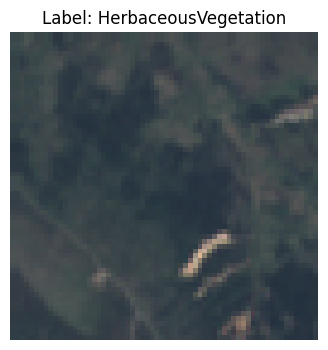

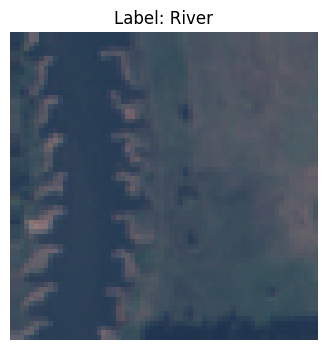

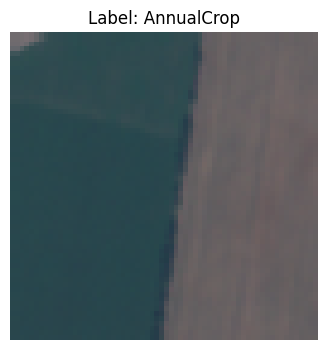

In [3]:
for i in torch.randint(len(datasets["train"]), (3,)):
    sample = datasets["train"][i]
    datasets["train"].plot(sample)

Two transforms, both from `eoml.data.eurosat`:

- **`get_preprocess()`** — `Normalize(0, 10000)`, scaling raw Sentinel-2 digital numbers to roughly [0, 1]. This exact transform is reused at inference time on downloaded scenes, so the model always sees identical inputs.
- **`get_augment()`** — random horizontal/vertical flips, training only.

In [4]:
preprocess = eurosat.get_preprocess().to(device)
augment = eurosat.get_augment().to(device)

## 2. Train the classifier

A ResNet-18 with self-supervised MoCo weights pretrained on Sentinel-2 imagery (via torchgeo), plus a fresh 10-class head. Three epochs of fine-tuning reaches ~96% test accuracy.

CLI equivalent: `eoml-train --epochs 3 --checkpoint artifacts/eurosat_resnet18.pth`

In [5]:
model = models.create_classifier()
train.fit(model, dataloaders, device, epochs=3, preprocess=preprocess, augment=augment);

Epoch 0: loss=486.01, val accuracy=79%


Epoch 1: loss=227.90, val accuracy=92%


Epoch 2: loss=91.67, val accuracy=95%


In [6]:
test_acc = train.evaluate(model, dataloaders["test"], device, preprocess)
print(f"Test accuracy: {test_acc:.1%}")

models.save_classifier(model, CHECKPOINT)
print(f"Saved checkpoint to {CHECKPOINT}")

Test accuracy: 94.4%
Saved checkpoint to ..\artifacts\eurosat_resnet18.pth


### Where does the model succeed, fail, and look?

The confusion matrix shows which classes get mixed up (typically the vegetation-adjacent ones: Permanent Crop vs Herbaceous Vegetation). Grad-CAM overlays show which pixels drove each prediction.

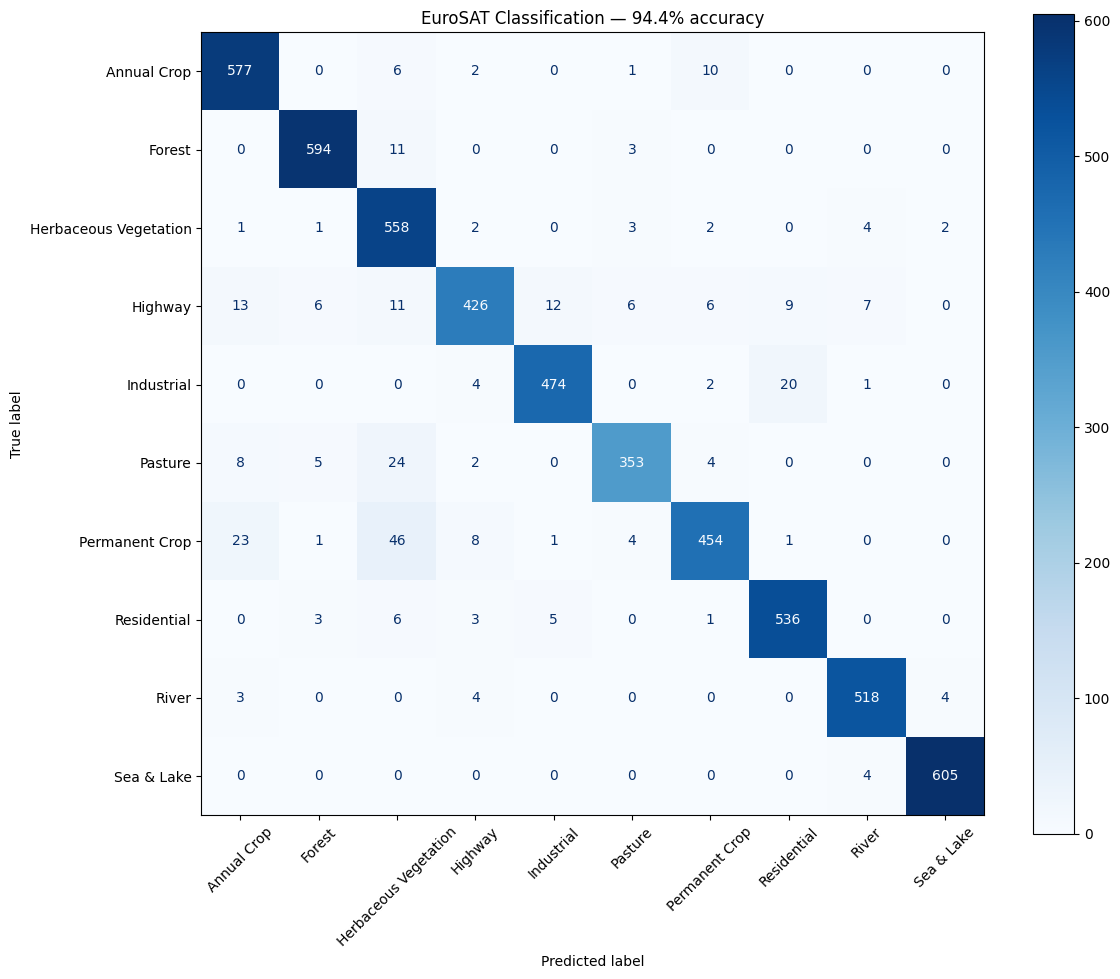

In [7]:
y_true, y_pred = train.predict(model, dataloaders["test"], device, preprocess)
viz.plot_confusion_matrix(y_true, y_pred);

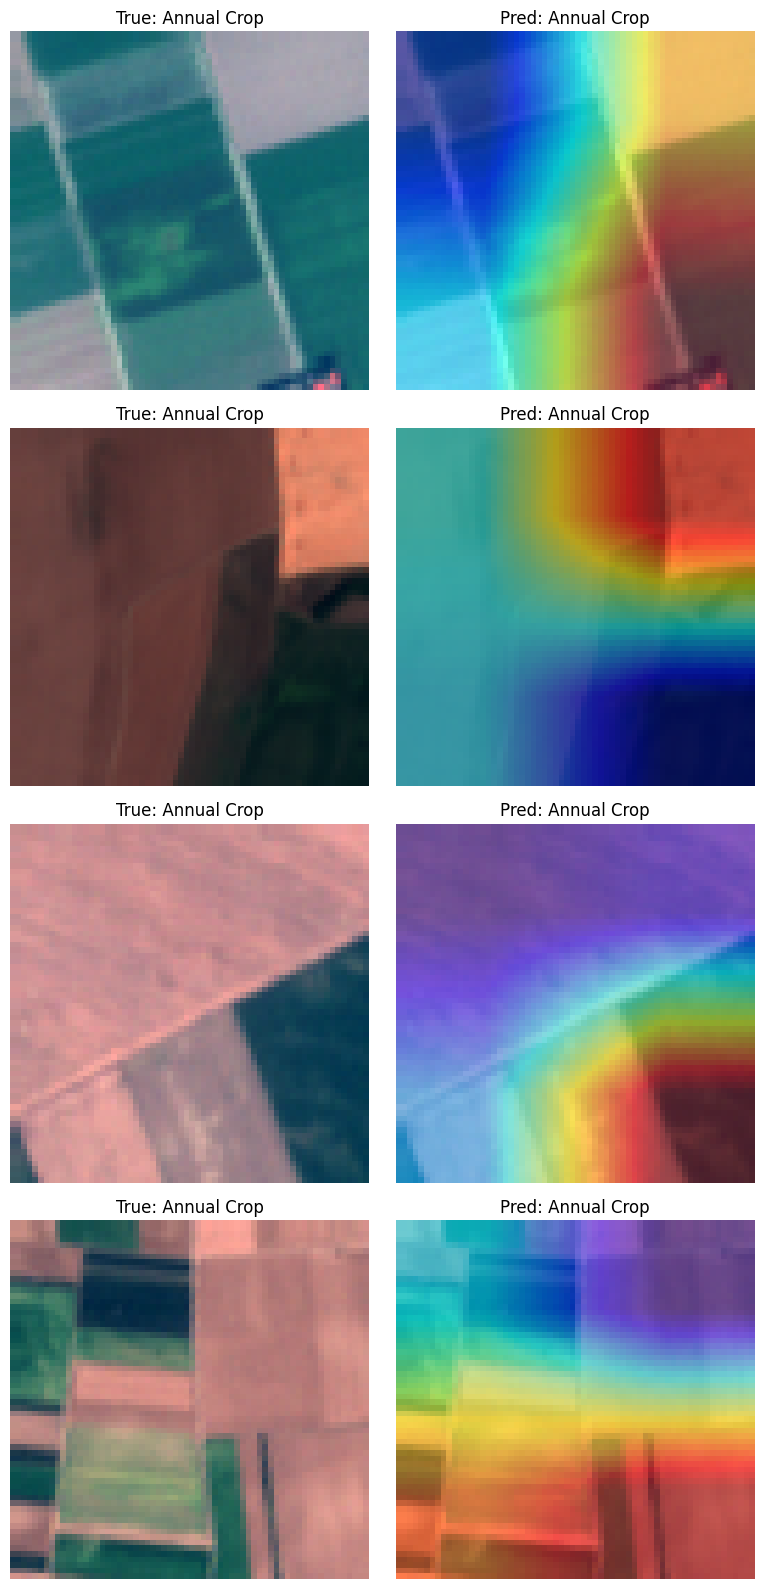

In [8]:
batch = next(iter(dataloaders["test"]))
viz.plot_gradcam_grid(model, batch["image"], batch["label"], device=device, n=4, preprocess=preprocess);

## 3. Retrieve an arbitrary Sentinel-2 scene

`eoml.data.scenes` searches the Planetary Computer STAC catalog for Sentinel-2 L2A scenes and loads any bbox as a single `(band, y, x)` DataArray: every band is clipped to the bbox and resampled onto the 10 m grid of B04, so the mixed 10/20/60 m bands stack cleanly.

Two subtleties handled here that a naive STAC query gets wrong:

- **Coverage**: STAC returns any granule *intersecting* the bbox — at swath edges that can be a nodata-padded sliver. `search_scenes` ranks results by bbox coverage first, cloud cover second.
- **Radiometric offset**: L2A scenes with processing baseline ≥ 04.00 (post-Jan 2022) carry a +1000 DN offset that EuroSAT-era data lacks. `load_band` subtracts it, so the classifier and NDVI see values on the scale they expect.

Here: an agricultural stretch of California's Central Valley — good variety for the classifier (crops, orchards, bare soil, the odd building).

In [9]:
bbox = [-120.5, 36.6, -120.35, 36.7]  # (west, south, east, north), ~13 x 11 km
items = scenes.search_scenes(bbox, "2024-06-01/2024-06-30", max_cloud_cover=20)
print(f"Found {len(items)} scenes")

item = items[0]  # best bbox coverage, then least cloudy
print(f"Using {item.id} (cloud cover {item.properties['eo:cloud_cover']:.1f}%, "
      f"covers {scenes.bbox_coverage(item, bbox):.0%} of bbox)")

Found 16 scenes
Using S2A_MSIL2A_20240629T183921_R070_T10SGF_20240630T032638 (cloud cover 0.0%, covers 100% of bbox)


In [10]:
scene = scenes.load_scene(item, bbox=bbox)
print(f"Scene: {scene.shape} (band, y, x), CRS: {scene.rio.crs}")

Scene: (12, 1146, 1372) (band, y, x), CRS: EPSG:32610


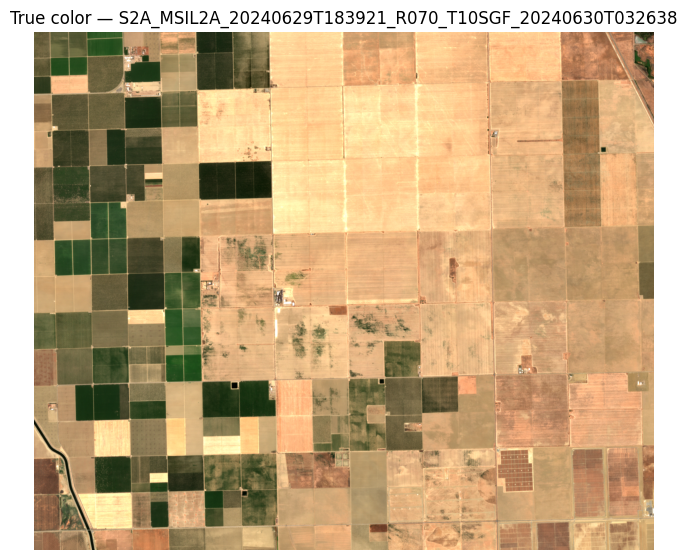

In [11]:
rgb = scene.sel(band=["B04", "B03", "B02"]).values.transpose(1, 2, 0)
rgb = np.clip(rgb / 3000, 0, 1)  # simple contrast stretch

plt.figure(figsize=(8, 7))
plt.imshow(rgb)
plt.axis("off")
plt.title(f"True color — {item.id}");

## 4. Run the classifier on the scene

This is the bridge between the two halves of the project (`eoml.inference`). The EuroSAT model expects 13-band L1C chips; the downloaded scene is a 12-band L2A raster of arbitrary size. `classify_scene`:

1. reorders bands to the EuroSAT layout and **zero-fills B10** (cirrus — absent from L2A, near zero over clear land anyway),
2. applies the same `Normalize(0, 10000)` used in training,
3. tiles the scene into 64×64 chips and classifies each in batches,
4. reassembles predictions into a class map carrying the scene's CRS — each output pixel covers one 640 m chip.

CLI equivalent: `eoml-classify --bbox -120.5 36.6 -120.35 36.7 --datetime 2024-06-01/2024-06-30`

Class map: (17, 21) chips


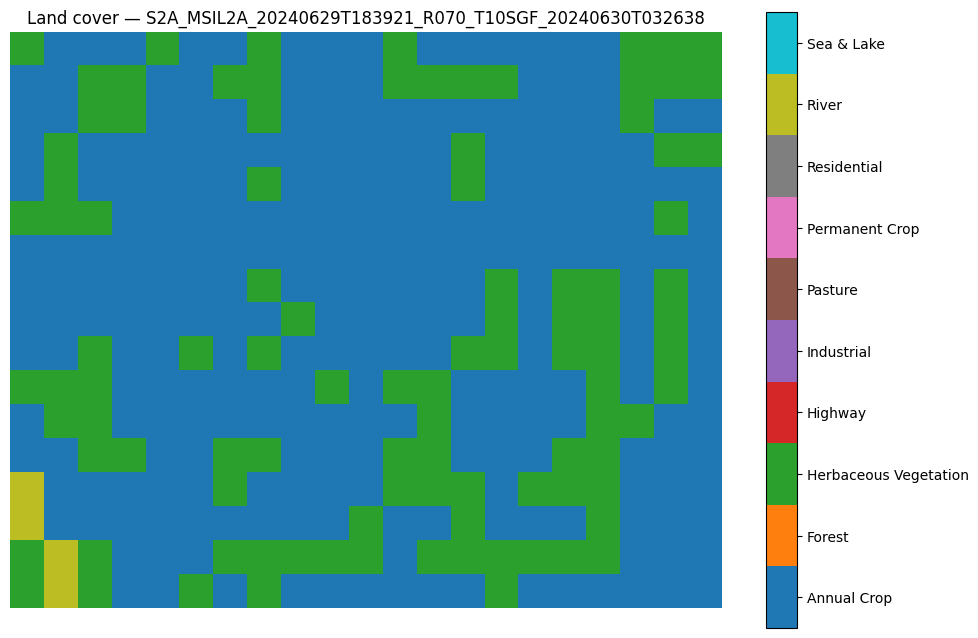

In [12]:
classifier = models.load_classifier(CHECKPOINT, device)
class_map = inference.classify_scene(classifier, scene, device)
print(f"Class map: {class_map.shape} chips")

viz.plot_class_map(class_map, title=f"Land cover — {item.id}");

## 5. NDVI analysis of the same scene

NDVI = (NIR − Red) / (NIR + Red), i.e. bands B08 and B04 — which are already in the loaded scene, so this reuses the exact same data with no second download.

CLI equivalent: `eoml-ndvi --bbox -120.5 36.6 -120.35 36.7 --datetime 2024-06-01/2024-06-30`

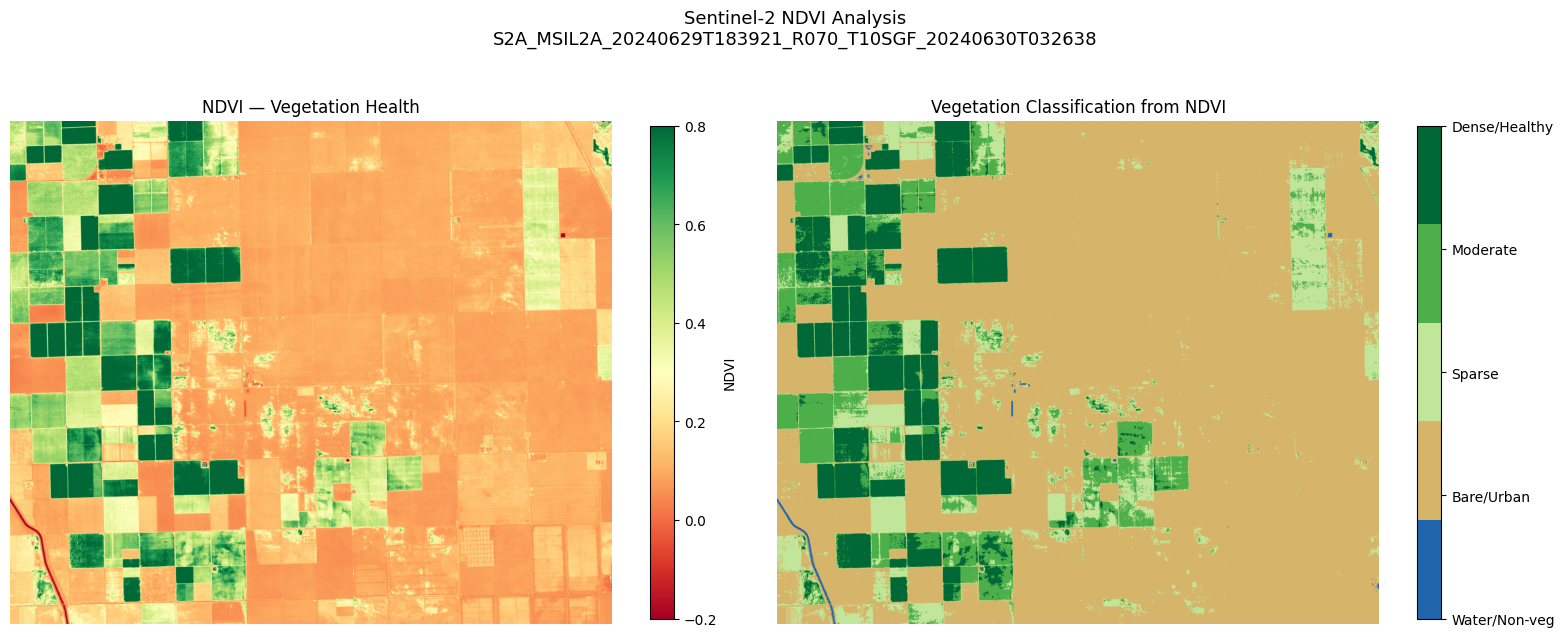

In [13]:
ndvi_da = indices.ndvi(scene)
veg_classes = indices.classify_ndvi(ndvi_da)

viz.plot_ndvi_analysis(ndvi_da, veg_classes, title=f"Sentinel-2 NDVI Analysis\n{item.id}");

## 6. Cross-check the two analyses

The two views are independent — the classifier is learned, NDVI is a fixed formula — so agreement between them is a useful sanity check: a scene dominated by crop/vegetation classes should also show high mean NDVI, and vice versa.

In [14]:
from collections import Counter

counts = Counter(class_map.values.ravel().tolist())
for idx, n in counts.most_common():
    print(f"{eurosat.CLASS_NAMES[idx]:25s} {n:4d} chips ({n / class_map.size:.0%})")

print(f"\nScene mean NDVI: {float(ndvi_da.mean()):.2f}")
print(f"Vegetated fraction (NDVI >= 0.2): {float((ndvi_da >= 0.2).mean()):.0%}")

Annual Crop                253 chips (71%)
Herbaceous Vegetation      100 chips (28%)
River                        4 chips (1%)

Scene mean NDVI: 0.23
Vegetated fraction (NDVI >= 0.2): 29%


---

That's the whole pipeline. To point it somewhere else, change `bbox` and `datetime` above — or skip the notebook entirely:

```sh
eoml-train --epochs 3
eoml-classify --bbox WEST SOUTH EAST NORTH --datetime 2024-06-01/2024-06-30
eoml-ndvi     --bbox WEST SOUTH EAST NORTH --datetime 2024-06-01/2024-06-30
```